In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder


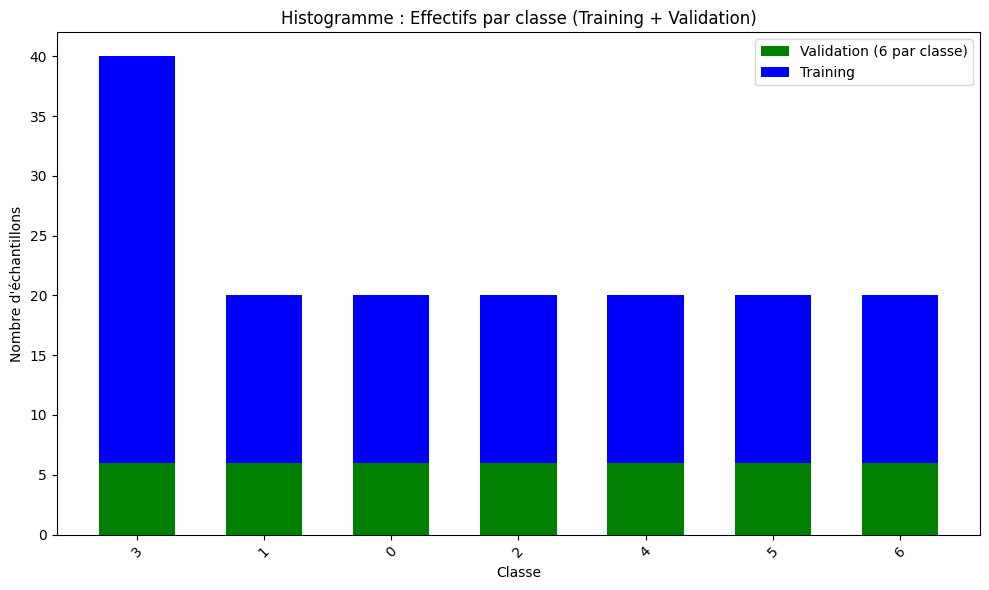

Epoch 10/100, Training Loss: 0.8751, Validation Loss: 1.0150
Epoch 20/100, Training Loss: 0.6182, Validation Loss: 0.8436
Epoch 30/100, Training Loss: 0.5058, Validation Loss: 0.7945
Epoch 40/100, Training Loss: 0.4182, Validation Loss: 0.7525
Epoch 50/100, Training Loss: 0.3513, Validation Loss: 0.7126
Epoch 60/100, Training Loss: 0.2793, Validation Loss: 0.6745
Epoch 70/100, Training Loss: 0.2448, Validation Loss: 0.6961
Epoch 80/100, Training Loss: 0.1804, Validation Loss: 0.6321
Epoch 90/100, Training Loss: 0.1334, Validation Loss: 0.5909
Epoch 100/100, Training Loss: 0.1063, Validation Loss: 0.5738


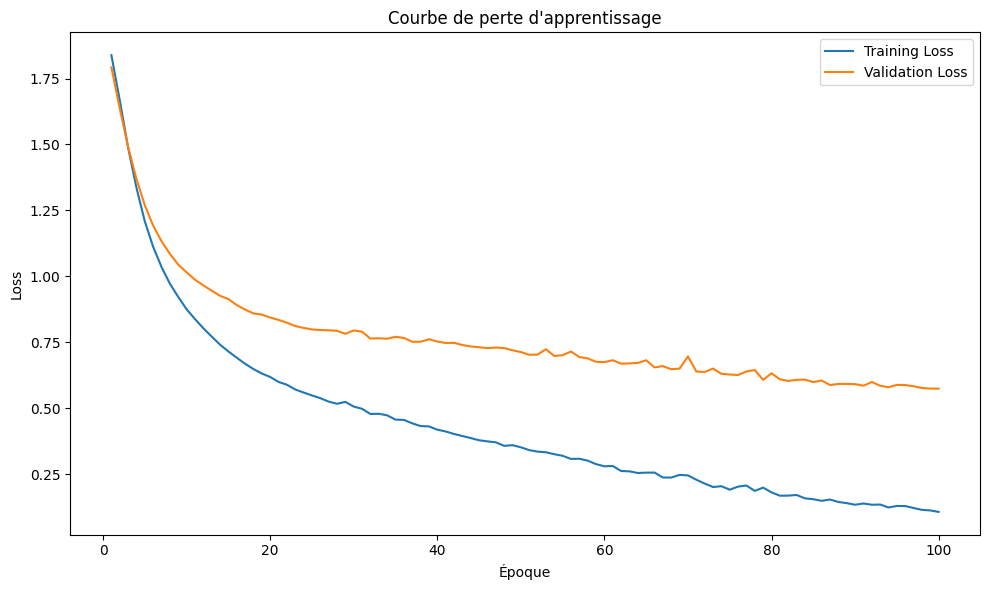


=== Validation Simple ===
Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.83      0.91         6
           2       0.83      0.83      0.83         6
           3       1.00      1.00      1.00         6
           4       0.86      1.00      0.92         6
           5       1.00      0.83      0.91         6
           6       0.83      0.83      0.83         6

    accuracy                           0.90        42
   macro avg       0.91      0.90      0.90        42
weighted avg       0.91      0.90      0.90        42



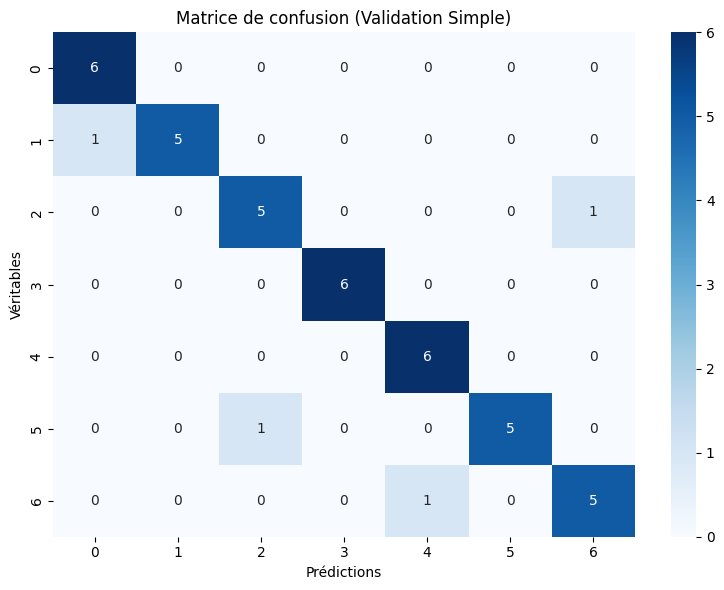

Score de Validation Simple : 0.9047619047619048


In [3]:

# ================================
# 1. Chargement et préparation des données
# ================================

# Charger les données
data_src = '../data/combined_data.csv'
data = pd.read_csv(data_src)

# On considère que la dernière colonne est la cible
target_col = data.columns[-1]

# Encodage de la cible (pour utiliser PyTorch, il faut des classes sous forme d'entiers)
le = LabelEncoder()
data[target_col] = le.fit_transform(data[target_col])
n_classes = data[target_col].nunique()

# Création du jeu de validation : 6 individus par classe
validation_frames = []
for specie in data[target_col].unique():
    specie_df = data[data[target_col] == specie]
    if len(specie_df) >= 6:
        val_specie = specie_df.sample(n=6, random_state=42)
    else:
        val_specie = specie_df.sample(n=6, replace=True, random_state=42)
    validation_frames.append(val_specie)
validation_data = pd.concat(validation_frames)

# Jeu d'entraînement = données restantes
training_data = data.drop(validation_data.index)

# Séparation en features et cible pour entraînement et validation
X_train = training_data.drop(columns=[target_col])
y_train = training_data[target_col]
X_val = validation_data.drop(columns=[target_col])
y_val = validation_data[target_col]

# Standardisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# ================================
# 2. Affichage de l'histogramme des effectifs par classe
# ================================

# Comptage des effectifs dans l'ensemble des données
full_counts = data[target_col].value_counts().sort_index()
# Comptage dans les jeux training et validation
train_counts = training_data[target_col].value_counts().sort_index()
val_counts = validation_data[target_col].value_counts().sort_index()

# Trier les classes par effectifs décroissants dans le training dataset
order = train_counts.sort_values(ascending=False).index
train_counts = train_counts.reindex(order)
val_counts = val_counts.reindex(order, fill_value=0)

species = order
x = np.arange(len(species))
width = 0.6

plt.figure(figsize=(10,6))
plt.bar(x, val_counts, width, color='green', label='Validation (6 par classe)')
plt.bar(x, train_counts, width, bottom=val_counts, color='blue', label='Training')
plt.xticks(x, species, rotation=45)
plt.xlabel("Classe")
plt.ylabel("Nombre d'échantillons")
plt.title("Histogramme : Effectifs par classe (Training + Validation)")
plt.legend()
plt.tight_layout()
plt.show()


# ================================
# 3. Validation simple avec réseau de neurones (PyTorch) et suivi de la loss
# ================================

# Paramètres d'entraînement
batch_size = 32
num_epochs = 100
learning_rate = 0.001

# Conversion des données en tenseurs
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

# Création des DataLoader pour l'entraînement
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Définition du modèle de réseau de neurones
class NeuralNet(nn.Module):
    def __init__(self, input_dim, hidden_dim1=64, hidden_dim2=32, output_dim=n_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim2, output_dim)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

input_dim = X_train_tensor.shape[1]
model = NeuralNet(input_dim)

# Utilisation du device GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Listes pour suivre la loss d'entraînement et de validation
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Calcul de la loss sur le jeu de validation
    model.eval()
    with torch.no_grad():
        outputs_val = model(X_val_tensor.to(device))
        loss_val = criterion(outputs_val, y_val_tensor.to(device)).item()
    val_losses.append(loss_val)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {epoch_loss:.4f}, Validation Loss: {loss_val:.4f}")

# Graphique de la perte d'apprentissage
plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.title("Courbe de perte d'apprentissage")
plt.legend()
plt.tight_layout()
plt.show()

# Évaluation sur le jeu de validation
model.eval()
with torch.no_grad():
    outputs = model(X_val_tensor.to(device))
    _, y_pred_tensor = torch.max(outputs, 1)
    y_pred = y_pred_tensor.cpu().numpy()

print("\n=== Validation Simple ===")
print("Classification Report:\n", classification_report(y_val, y_pred))
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion (Validation Simple)")
plt.xlabel("Prédictions")
plt.ylabel("Véritables")
plt.tight_layout()
plt.show()
print("Score de Validation Simple :", accuracy_score(y_val, y_pred))
